**The Ice & Snow Dynasty: Decoding Winter Olympic Success**

Every four years, the world turns its attention to the mountains and rinks for the Winter Olympics. But have you ever wondered what it takes to dominate the cold? Is it just about having the most athletes, or is there a secret recipe to Olympic glory?

In this post, we dive into the history of the Winter Games, from 1924 to today, to see how participation has exploded, which nations rule the podium, and how some countries have turned specific sports into national legacies.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

medals = pd.read_csv('winter_olympics_medals.csv')
bios = pd.read_csv('bios.csv')

medals = medals.dropna(subset=['year'])
medals['year'] = medals['year'].astype(int)

The Winter Olympics started as a relatively small gathering. However, over the last century, it has transformed into a massive global event. We can see this shift most clearly by looking at the sheer number of unique athletes competing in each cycle.

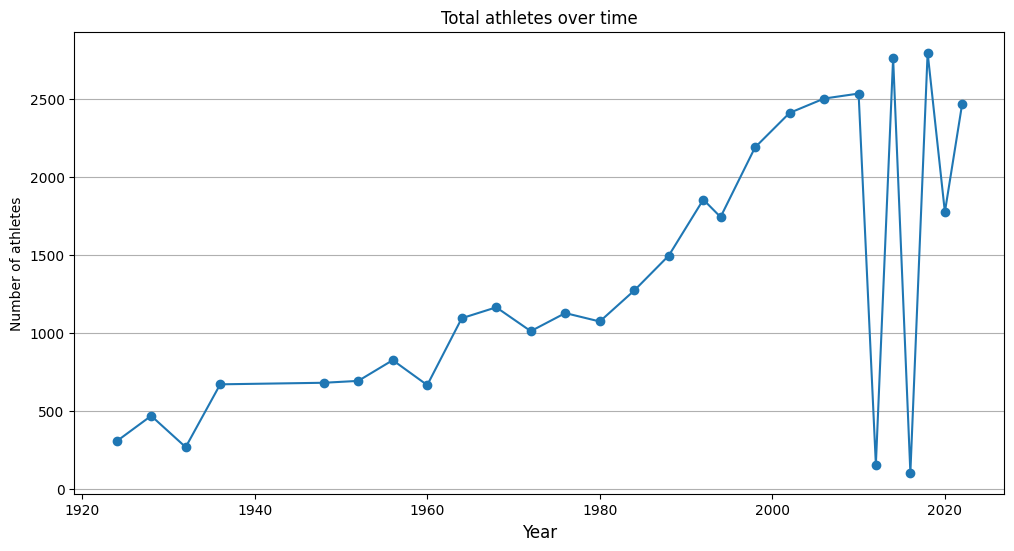

In [7]:
participation = medals.groupby('year')['athlete_id'].nunique()

plt.figure(figsize=(12, 6))
plt.plot(participation.index, participation.values, marker='o')
plt.title('Total athletes over time')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of athletes')
plt.grid(axis='y')
plt.show()

The chart shows a dramatic upward trajectory, particularly after the 1980s. As more events were added, the event was inviting thousands of athletes to compete for glory.

Amonst all these participants, representing their countries, which countries stood dominant? 

**Who Owns the Podium?**

While many countries participate, a select few have historically dominated the medal counts. By aggregating all medals (Gold, Silver, and Bronze) across history, we can identify the true titans of winter.

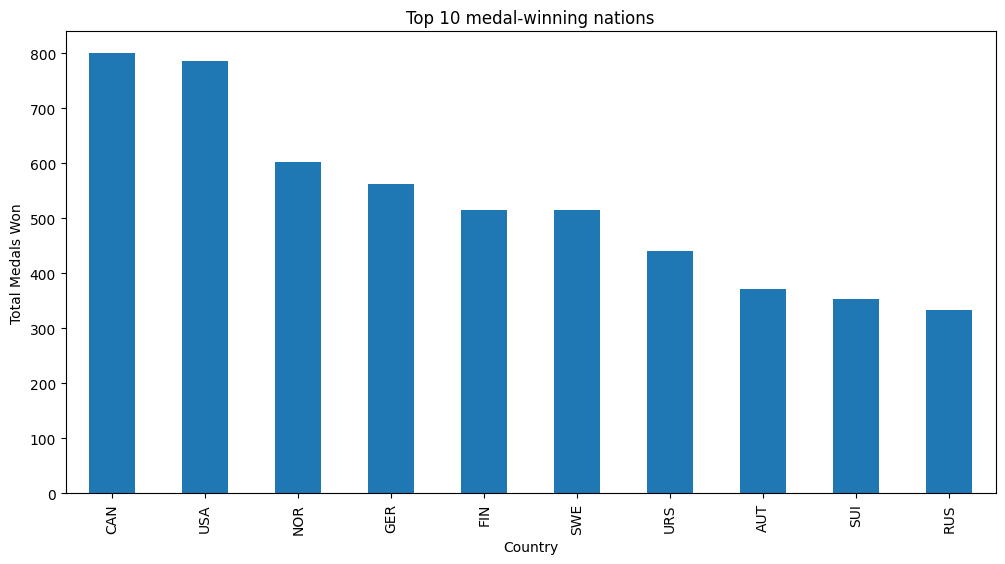

In [9]:
medal_winners = medals.dropna(subset=['medal'])
top_countries = medal_winners.groupby('noc').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar')
plt.title('Top 10 medal-winning nations')
plt.xlabel('Country')
plt.ylabel('Total Medals Won')
plt.show()

Canada stands just ahead of the USA but both countries stand out as the consistent powerhouses, achieving just under 800 medals each. Norway's presence at the top is particularly impressive given its relatively small population. This proves that climate and culture often outweigh size when it comes to winter sports.

**Do we have specialists who dominate certain sports?**

Success isn't always about being good at everything. Some nations have mastered the art of "Specialization." Take the Netherlands (NED) for example. While they are a consistent medal-winner, their success is almost entirely concentrated in one arena.

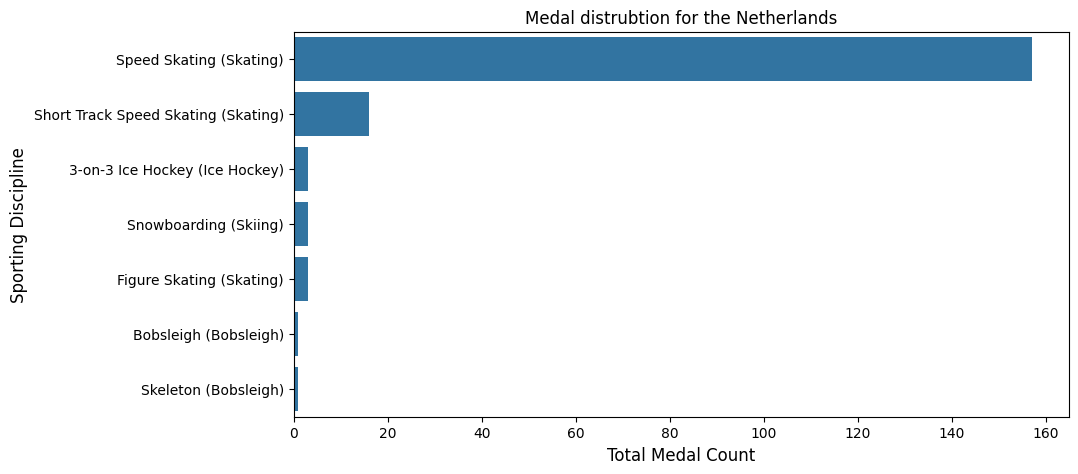

In [12]:
ned_medals = medal_winners[medal_winners['noc'] == 'NED'].groupby('discipline').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=ned_medals.values, y=ned_medals.index)
plt.title('Medal distrubtion for the Netherlands')
plt.xlabel('Total Medal Count', fontsize=12)
plt.ylabel('Sporting Discipline', fontsize=12)
plt.show()

Almost every medal of theirs comes from Speed Skating! They have won 180+ medals in this sport alone, and close to none is most other sports! 

The Netherlands' dominance in Speed Skating is staggering. It accounts for the vast majority of their success at the Winter Olympics. This specialization strategy allows smaller nations to build world-class infrastructure and training programs for specific sports, ensuring a steady stream of medals.

This specialization strategy is not just for the small countries though!

For Canada, the Winter Olympics is often defined by the performance of a single team. While Canada is strong in many sports, Ice Hockey represents the heartbeat of their Olympic identity.

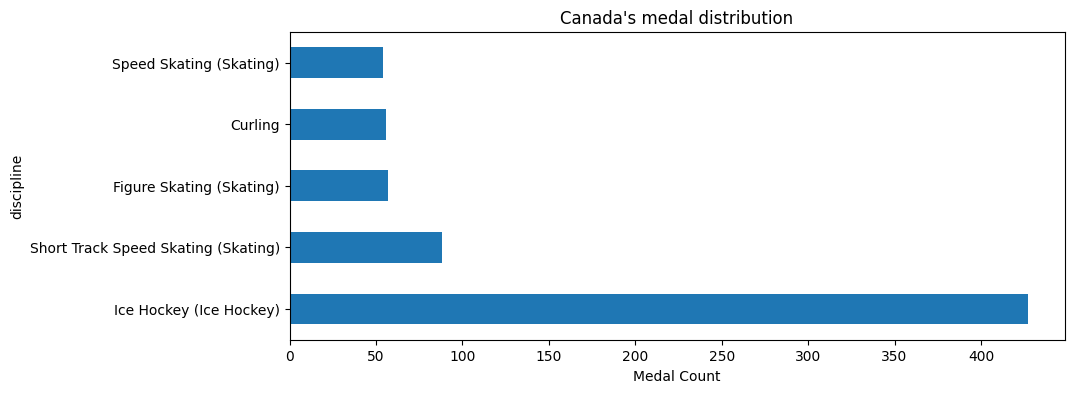

In [18]:
can_medals = medal_winners[medal_winners['noc'] == 'CAN'].groupby('discipline').size().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 4))
can_medals.plot(kind='barh')
plt.title("Canada's medal distribution")
plt.xlabel('Medal Count')
plt.show()

Canada's ice hockey team alone has won around 450 medals! That's more than the total medals won by some of the countries featured in the Top 10 list. While Canada's olympic contingent has performed well in many other sports, even Canada has their speciality!

While Norway rules the cross-country trails, **Austria** has turned the mountain slopes into their personal podium.

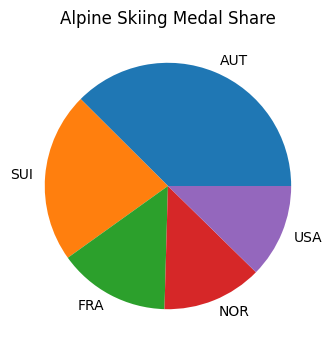

In [20]:
alpine_medals = medal_winners[medal_winners['discipline'].str.contains('Alpine Skiing', na=False)]
top_alpine = alpine_medals.groupby('noc').size().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 4))
top_alpine.plot(kind='pie')
plt.title('Alpine Skiing Medal Share')
plt.ylabel('')
plt.show()

A small country like Austria dominates the slopes! It has only about 400 total medals, which is about half of the number USA or Canada has. Still, nonetheless, in their specialty, they outperform every other country and dominate their sport, having won more medals in Alpine Skiing than anyone else!

**Specialists vs. Generalists**

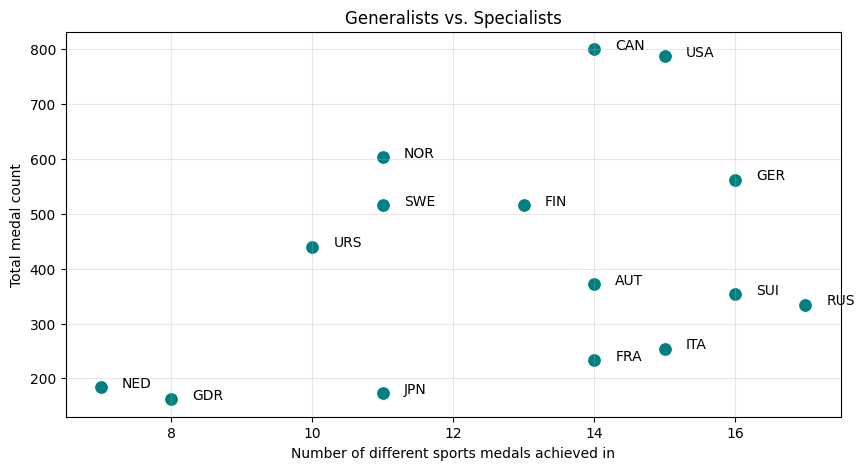

In [25]:
top_15 = (medal_winners.groupby('noc').agg(medals=('medal', 'count'), diversity=('discipline', 'nunique')).sort_values('medals', ascending=False).head(15))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=top_15, x='diversity', y='medals', s=100, color='teal')

for noc, row in top_15.iterrows():
    plt.text(row['diversity'] + 0.3, row['medals'], noc)

plt.title('Generalists vs. Specialists')
plt.xlabel('Number of different sports medals achieved in')
plt.ylabel('Total medal count')
plt.grid(True, alpha=0.3)
plt.show()

Countries like the USA and Canada sit at the top right because they win across many sports, even if they do have a sport where they dominate disproportionately.

On the other hand, countries like the Netherlands sit higher up on the total medal count than the number of sports. They don't need to compete in 15 sports to be a top-10 nation because by just achieving medals in their specialty, they make a huge mark.

**Conclusion**

The data reveals that there isn't just one way to win. You can be a global winter titan by dominating the entire map, or you can build a cultural dynasty around a single sheet of ice or a specific mountain peak. As the Games evolve, the fight between the "all-rounders" and the "specialists" continues to be the most fascinating subplot of the Winter Olympics.